In [1]:
# Advanced customization of charts

In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

df = pd.read_csv('C:/Users/jhonn/Downloads/data_jobs.csv')

#Cleaning the date 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
def clean_list (skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)
df['job_skills'] = df['job_skills'].apply(clean_list)

#Filter for Data analyst data
df_DA = df[df['job_title_short']=='Data Analyst'].copy()

In [2]:
#Month
df_DA['month'] = df_DA['job_posted_date'].dt.month

In [3]:
# Explode Skills
df_explode = df_DA.explode('job_skills')
df_explode.head(2)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,month
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,r,"{'analyst_tools': ['power bi', 'tableau'], 'pr...",1
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,python,"{'analyst_tools': ['power bi', 'tableau'], 'pr...",1


In [4]:
df_pivot = df_explode.pivot_table(index='month', columns='job_skills', fill_value=0, aggfunc='size')

In [5]:
Top_Skills = df_explode['job_skills'].value_counts().head(5).index
type(Top_Skills)

pandas.core.indexes.base.Index

In [6]:
df_pivot[Top_Skills]

job_skills,sql,excel,python,tableau,power bi
month,,,,,
1,11336,8170,6606,5596,4285
2,7947,5772,4751,3936,3307
3,7868,5675,4741,4051,3176
4,7553,5496,4557,3776,3106
5,6617,4773,4070,3245,2695
6,7584,5724,4707,3812,3275
7,7687,5513,4831,3928,3350
8,8823,6482,5576,4533,3859
9,6829,4886,4229,3446,3118


In [7]:
month_mapping = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}
df_pivot = df_pivot.rename(index=month_mapping)
df_toppivot = df_pivot[Top_Skills]


# Customize your graphic

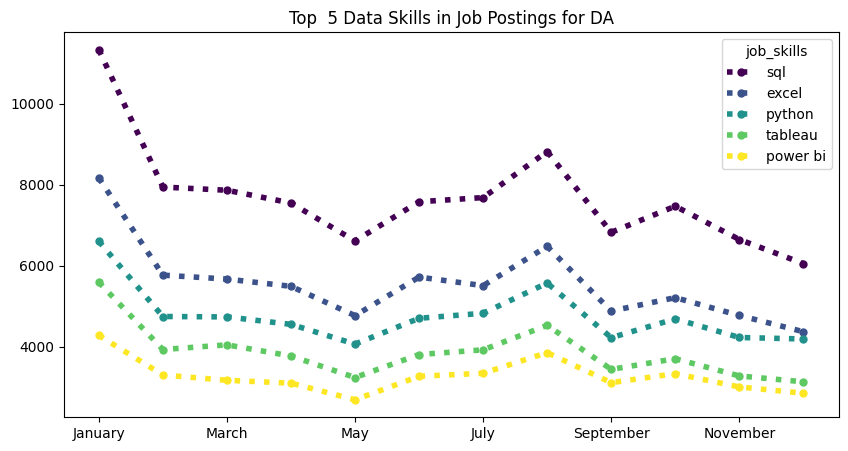

In [20]:
# linestyle = '-', '..', '-.', ':' marker = '*', 'o'
df_toppivot.plot(kind='line', linewidth= 4, linestyle=':', colormap= 'viridis', marker ='o', markersize = 5, figsize=(10,5))
plt.title('Top  5 Data Skills in Job Postings for DA')
plt.xlabel('')
plt.show()

In [21]:
skill_stats= df_explode.groupby(['job_skills']).agg(
    skill_count=('job_skills', 'count'),
    median_salary = ('salary_year_avg', 'median')
).sort_values(by='skill_count', ascending=False).head(20)
skill_stats

,skill_count,median_salary
job_skills,,
sql,92428,92500.000000
excel,66860,84479.000000
python,57190,98500.000000
tableau,46455,95000.000000
power bi,39380,90000.000000
r,29996,92527.500000
sas,27998,90000.000000
powerpoint,13822,85000.000000
word,13562,80000.000000



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


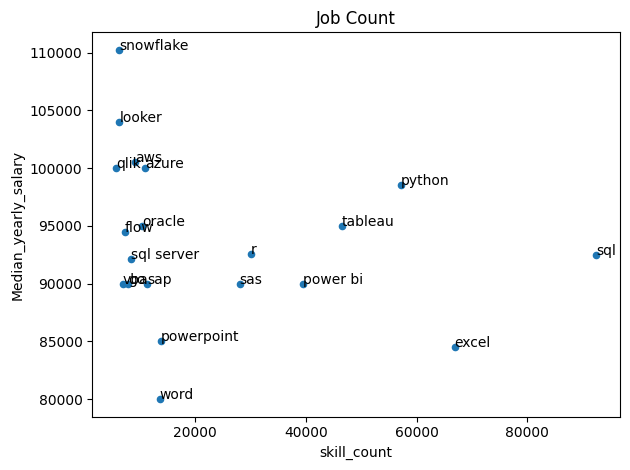

In [ ]:
!pip install adjustText
from adjustText import adjust_text



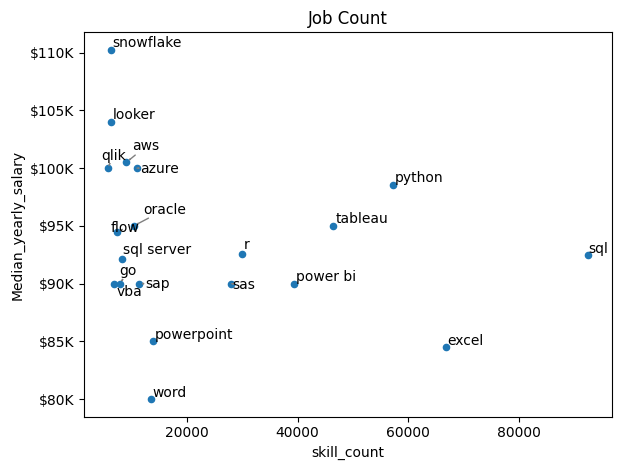

In [46]:
#fig, ax = plt.subplots()
#ax=plt.gca()
skill_stats.plot(kind='scatter', x='skill_count' , y='median_salary')
plt.title('Job Count')
plt.ylabel('Median_yearly_salary')
plt.tight_layout()

texts = []

for i, txt in enumerate(skill_stats.index):
    texts.append (plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
adjust_text(texts, arrowprops = dict(arrowstyle="->", color='gray', lw=1))
    
plt.show()